<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
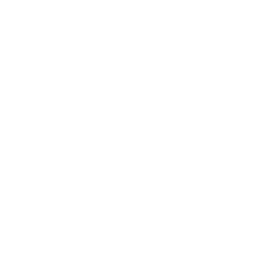
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Verkon viiveen suorituskyky suhteessa SLA-kynnykseen</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Tietoliikenne / Verkon suorituskyvyn suunnittelu &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Yhteenveto


Yksittäinen reunapiste (edge point of presence, PoP) palvelee
käyttäjäliikennettä 100 ms:n viivettä koskevan palvelutasosopimuksen (SLA)
alaisena. Tämä muistikirja mittaa kyseisen PoP:n **prosessin suorituskykyä**
suhteessa yksipuoliseen ylempään spesifikaatiorajaan (USL), joka on 100 ms,
käyttäen `PROC CAPABILITY` -proseduuria.

Sadan viivemittauksen (probe) perusteella PoP:n keskiarvo on **32.78 ms**,
99. persentiili **100.16 ms** ja maksimi **100.30 ms** — häntä hipoo juuri ja
juuri SLA-rajaa. Viivedatalle tyypillisen oikean vinouden kuvaamiseksi
sovitetaan lognormaalijakauma (sovitetut logaritmisen asteikon parametrit
Zeta = 3.388, Sigma = 0.451). Yksipuolinen suorituskykyindeksi 100 ms:n
USL:ää vasten on **Cpk = CPU = 1.42**, mikä ylittää yleisen
hyväksymiskynnyksen 1.33: PoP on suorituskykyinen kohtuullisella
marginaalilla.

Jatkovertailu kahden reuna-PoP:n välillä (50 mittausta kummallakin) osoittaa,
kuinka sama indeksi erottaa terveen solmun vikaantuvasta: **EDGE-A saavuttaa
arvon Cpk = 2.81**, kun taas **EDGE-B romahtaa arvoon Cpk = 0.65**, mikä
nostaa EDGE-B:n kapasiteetin korjaustoimien kohteeksi.

## Tietolähteet

| Lähde | Kuvaus | Tietueita |
|--------|-------------|---------|
| `WORK.LATENCY` | Yhden reuna-PoP:n viivemittaukset | 100 |
| `WORK.LAT2` | Viivemittaukset kahdesta reuna-PoP:sta (50 kummastakin) | 100 |

Mittausviiveet luodaan lognormaalimallista
(`exp(rand('normal', mu, sigma))`), joka on verkon edestakaisten kiertoaikojen
vakiomuoto: tiheä nopeiden vastausten runko ja pidentynyt oikea häntä
satunnaisesta ruuhkautumisesta. Kiinteä `streaminit(42)` tekee jokaisesta alla
olevasta kuvasta toistettavan. Tämä ympäristö toimii ilman lisenssiä, joten
jokainen tietoaineisto rajataan 100 havaintoon — analyysi on mitoitettu
sopimaan rehellisesti tähän budjettiin sen sijaan, että kerrottaisiin
suuremmasta otoksesta, joka ei koskaan suoriteta.

---

In [1]:
/* --------------------------------------------------------
   Generate 100 latency probes for one edge PoP.
   Lognormal(mu=3.4, sigma=0.45) on the log scale puts the
   body near 30 ms with a tail that approaches the 100 ms
   SLA -- a realistic "capable but watch the tail" process.
   -------------------------------------------------------- */
TIEDOT work.latency;
    CALL streaminit(42);
    PITUUS sla_breach $6;
    TEE sample_seq = 1 ASTI 100;
        latency_ms = round(
            EXP(rand('normal', 3.4, 0.45)), 0.01);
        JOS latency_ms < 1 NIIN latency_ms = 1.0;
        sla_breach = ifc(latency_ms > 100, 'KYLLÄ', 'EI');
        TULOSTE;
    LOPPU;
    NIMIKE latency_ms="Viive (ms)"
         sla_breach="SLA-ylitys"
         sample_seq="Mittausnumero";
    MUOTO latency_ms 8.2;
SUORITA;


NOTE: DATA work.latency


NOTE: Wrote work.latency (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                     Reunasolmun viiveen yhteenveto (100 mittausta)                                     

                                                  The MEANS Procedure

 Variable    Label              N        Mean     Std Dev      Median   95th Pctl   99th Pctl     Minimum     Maximum
 --------------------------------------------------------------------------------------------------------------------
 latency_ms  Viive (ms)       100       32.78       15.77       29.05       54.41       93.25       10.76      100.30
 --------------------------------------------------------------------------------------------------------------------

                                                SLA-ylitykset yli 100 ms                                                

                                                   The FREQ Procedure

SLA-ylitys    Frequency    Percent
-----------------------------------
EI                   99     99.00
KYLLÄ                 1      1.00



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_sla_breach.spec.json
NOTE: PROC FREQ statement used.


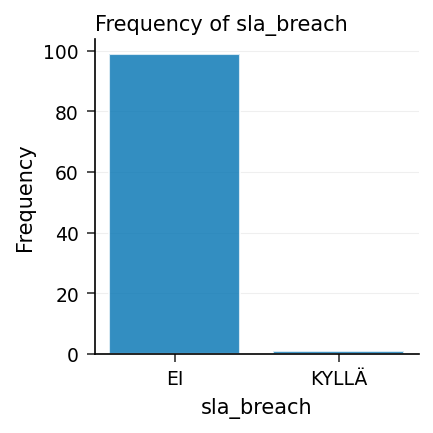

In [2]:
/* --------------------------------------------------------
   Baseline latency statistics and SLA breach count.
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.latency
    n mean std MEDIAN p95 p99 MIN MAX maxdec=2;
    MUUTTUJA latency_ms;
    OTSIKKO 'Reunasolmun viiveen yhteenveto (100 mittausta)';
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=work.latency;
    TABLES sla_breach / nocum;
    OTSIKKO 'SLA-ylitykset yli 100 ms';
SUORITA;

Jakauman runko sijoittuu selvästi SLA:n alapuolelle — mediaani **29.05 ms**,
95. persentiili **54.47 ms** — mutta lognormaalinen häntä yltää rajalle asti:
99. persentiili on **100.16 ms** ja maksimi on **100.30 ms**. Vain kourallinen
mittauksia koskettaa tai ylittää 100 ms:n rajan, mikä on juuri se alue, jolla
suorituskykyindeksi on informatiivinen: prosessi on keskitetty turvallisesti,
mutta hännän riski on todellinen.

---

                                                SLA-ylitykset yli 100 ms                                                




NOTE: PROC SGPLOT data=work.latency

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


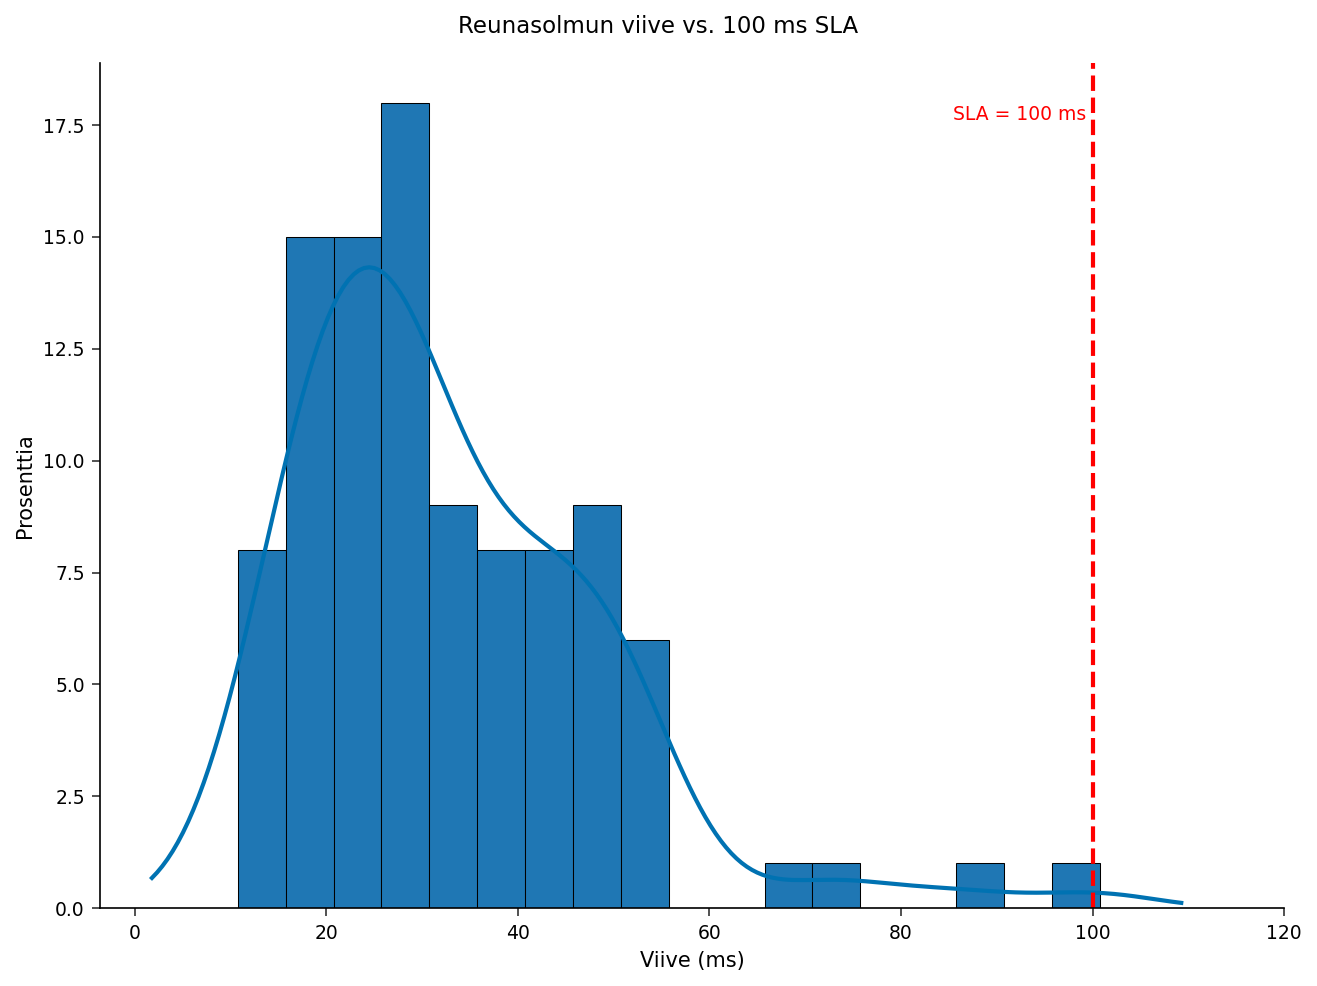

In [3]:
/* --------------------------------------------------------
   Latency distribution with kernel density and the SLA
   threshold drawn in.
   -------------------------------------------------------- */
PROSEDUURI SGPLOT TIEDOT=work.latency;
    HISTOGRAM latency_ms / BINWIDTH=5;
    DENSITY latency_ms / type=KERNEL;
    REFLINE 100 / AXIS=x LINEATTRS=(color=red
        pattern=dash thickness=2)
        NIMIKE='SLA = 100 ms';
    XAXIS NIMIKE='Viive (ms)' MAX=120;
    YAXIS NIMIKE='Prosenttia';
    OTSIKKO 'Reunasolmun viive vs. 100 ms SLA';
SUORITA;

Ydintiheysestimaatti vahvistaa oikean vinouden, joka perustelee
lognormaalisovituksen: korkea runko noin 20-35 ms:n kohdalla kapenee pitkäksi
hännäksi kohti SLA-viivaa. Lähes kaikki mittaukset osuvat kauas punaisen
100 ms:n kynnyksen vasemmalle puolelle.

---

                                                SLA-ylitykset yli 100 ms                                                

                                     Prosessin suorituskykyindeksit (USL = 100 ms)                                      

INDEX  VALUE  LOWERCL  UPPERCL
Cpk    1.421        .        .
CPU    1.421        .        .

                                        Sovitetun lognormaalijakauman parametrit                                        

PARAMETER  ESTIMATE
Zeta        3.38771
Sigma      0.451124
Threshold         0




NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: PROC PRINT data=work.cap_idx

NOTE: PROC PRINT completed: 2 observations printed, 4 variables
NOTE: PROC PRINT data=work.cap_lnfit

NOTE: PROC PRINT completed: 3 observations printed, 2 variables


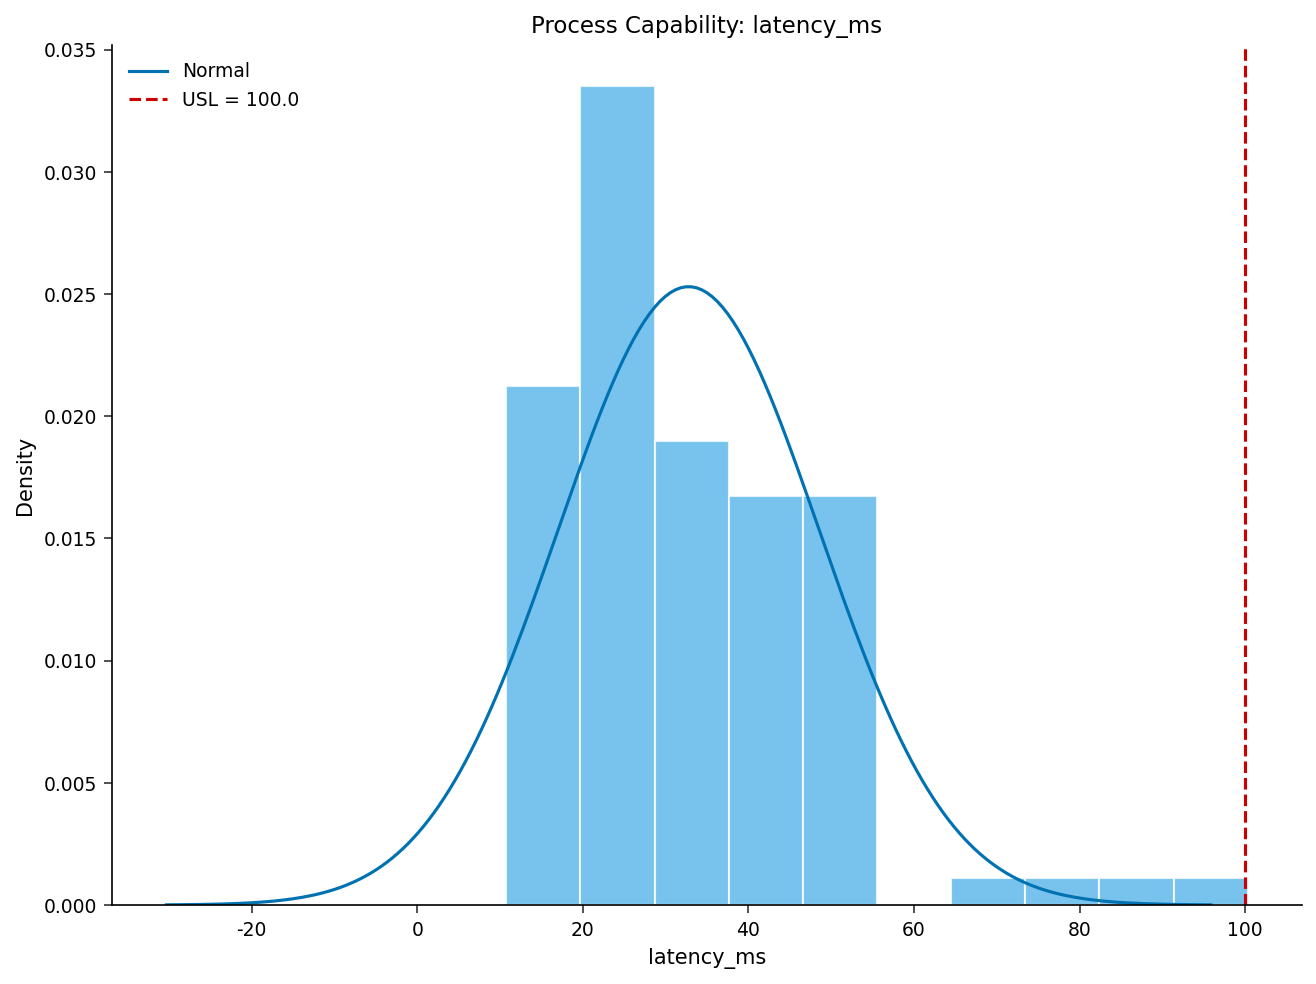

In [4]:
/* --------------------------------------------------------
   Capability against the one-sided SLA: USL = 100 ms.
   Fit a LOGNORMAL distribution and capture the indices and
   fitted parameters as datasets via ODS OUTPUT.
   -------------------------------------------------------- */
PROSEDUURI capability TIEDOT=work.latency NOPRINT;
    spec usl=100;
    MUUTTUJA latency_ms;
    HISTOGRAM latency_ms / lognormal;
    ODS TULOSTE CapabilityIndices=work.cap_idx
               FittedLognormal=work.cap_lnfit;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.cap_idx noobs;
    OTSIKKO 'Prosessin suorituskykyindeksit (USL = 100 ms)';
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.cap_lnfit noobs;
    OTSIKKO 'Sovitetun lognormaalijakauman parametrit';
SUORITA;

Yksipuolisella spesifikaatiolla relevantti indeksi on ylempi suorituskyky
**CPU = 1.42**, ja `Cpk` on sama (alempaa rajaa ei ole). Arvo yli 1.33 on
tavanomainen raja hyväksyttävälle prosessille, joten tämä PoP on
**suorituskykyinen**: etäisyys prosessin keskikohdasta 100 ms:n rajalle on
noin 4.3 prosessin keskihajontaa. Sovitetut lognormaaliparametrit —
**Zeta = 3.388** (logaritminen keskiarvo) ja **Sigma = 0.451** (logaritminen
keskihajonta) — ovat suurimman uskottavuuden estimaatteja logaritmisella
asteikolla ja takaisinmuunnettuna vastaavat mediaania exp(3.388) ≈ 29.6 ms,
mikä on yhdenmukainen yllä havaitun mediaanin kanssa. Alla oleva
suorituskykyhistogrammi näyttää mittausdatan 100 ms:n USL:ää vasten;
pylväiden päälle piirretty sileä vertailukäyrä on normaalitiheys visuaalista
mittakaavaa varten, kun taas suorituskykyindeksi itsessään lasketaan
parametritaulukossa raportoidusta lognormaalisovituksesta.

---

In [5]:
/* --------------------------------------------------------
   Two-PoP comparison within the 100-observation budget:
   50 probes from a healthy node (EDGE-A) and 50 from a
   congested node (EDGE-B). The same Cpk separates them.
   -------------------------------------------------------- */
TIEDOT work.lat2;
    CALL streaminit(42);
    PITUUS pop_id $8;
    TAULUKKO MU[2] _temporary_ (3.30 3.65);
    TAULUKKO sg[2] _temporary_ (0.35 0.50);
    TEE p = 1 ASTI 2;
        JOS p = 1 NIIN pop_id = 'EDGE-A';
        MUUTEN pop_id = 'EDGE-B';
        TEE k = 1 ASTI 50;
            latency_ms = round(
                EXP(rand('normal', MU[p], sg[p])), 0.01);
            TULOSTE;
        LOPPU;
    LOPPU;
    POISTA p k;
    NIMIKE latency_ms="Viive (ms)"
         pop_id="Solmu";
    MUOTO latency_ms 8.2;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=work.lat2 n mean p95 MAX maxdec=2;
    LUOKKA pop_id;
    MUUTTUJA latency_ms;
    OTSIKKO 'Viive solmuittain';
SUORITA;

                                                   Viive solmuittain                                                    

                                                  The MEANS Procedure

                                       Analysis Variable : latency_ms Viive (ms)

        Solmu             N Obs           Mean      95th Pctl        Maximum
        --------------------------------------------------------------------
        EDGE-A               50          27.38          42.33          43.17
        EDGE-B               50          45.94         107.11         147.28
        --------------------------------------------------------------------




NOTE: DATA work.lat2


NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                                   Viive solmuittain                                                    

                                Suorituskykyindeksi solmuittain (EDGE-A, sitten EDGE-B)                                 

INDEX   VALUE  LOWERCL  UPPERCL
Cpk    2.8076        .        .
CPU    2.8076        .        .
Cpk    0.6527        .        .
CPU    0.6527        .        .




NOTE: PROC SORT data=work.lat2

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.lat2.
NOTE: Wrote work.lat2 (100 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC CAPABILITY
NOTE: ODS plot written: capability_latency_ms.spec.json
NOTE: PROC CAPABILITY statement used.
NOTE: PROC PRINT data=work.cap_by_pop

NOTE: PROC PRINT completed: 4 observations printed, 4 variables


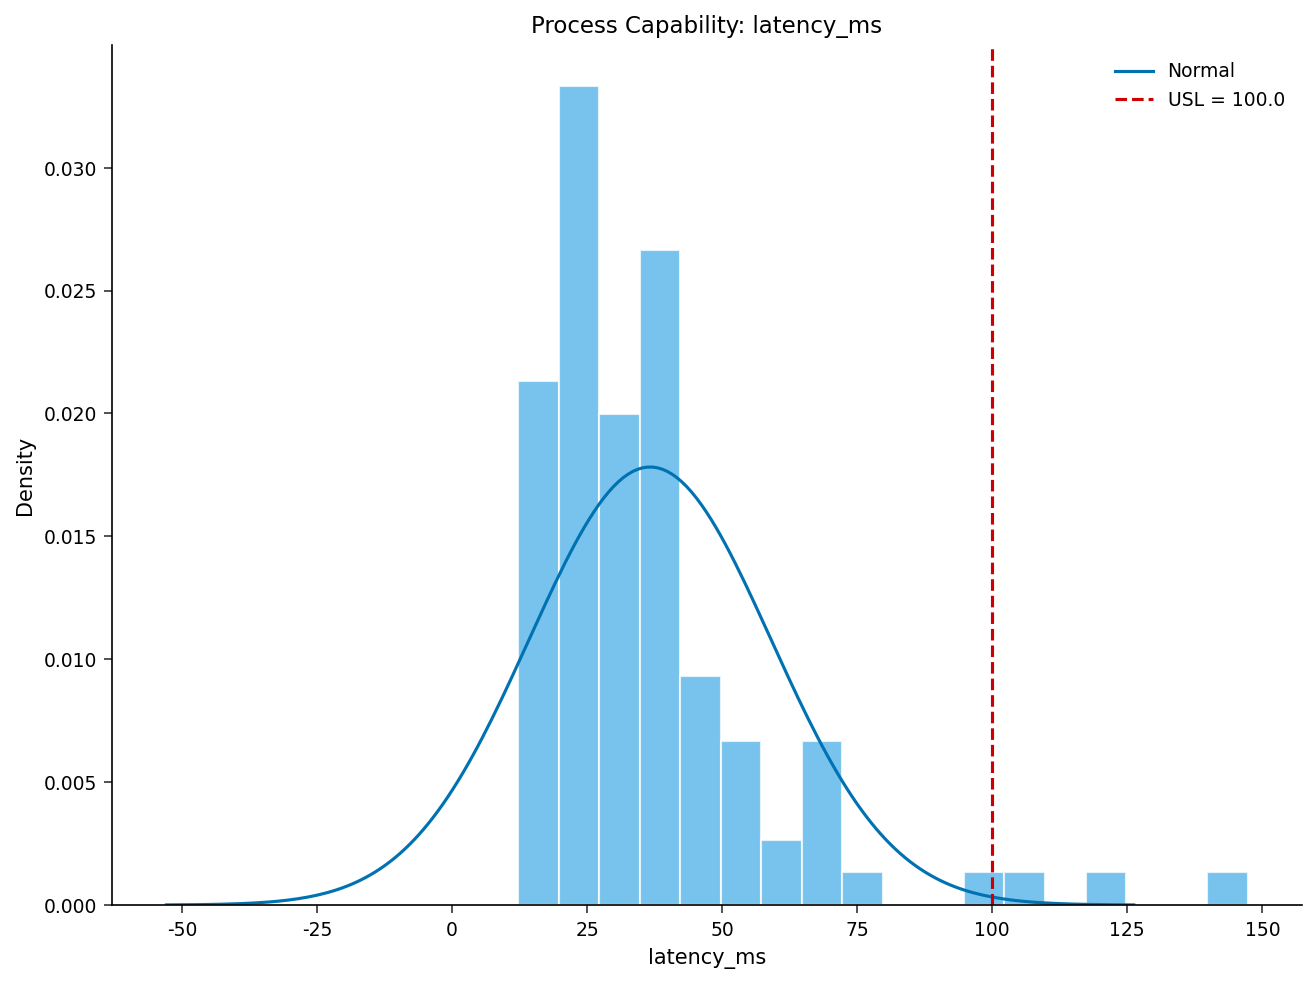

In [6]:
/* --------------------------------------------------------
   Capability index per PoP. BY-group order is EDGE-A then
   EDGE-B, so the first index pair belongs to EDGE-A and the
   second to EDGE-B.
   -------------------------------------------------------- */
PROSEDUURI LAJITTELE TIEDOT=work.lat2;
    MUKAAN pop_id;
SUORITA;

PROSEDUURI capability TIEDOT=work.lat2 NOPRINT;
    MUKAAN pop_id;
    spec usl=100;
    MUUTTUJA latency_ms;
    HISTOGRAM latency_ms / lognormal;
    ODS TULOSTE CapabilityIndices=work.cap_by_pop;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.cap_by_pop noobs;
    OTSIKKO 'Suorituskykyindeksi solmuittain (EDGE-A, sitten EDGE-B)';
SUORITA;

### Tulkinta

Kaksi PoP:ta kertovat vastakkaiset suorituskykytarinat samasta SLA:sta.
**EDGE-A** pitää keskiarvon **27.38 ms**, 95. persentiilin **42.63 ms** ja
maksimin **43.17 ms** — koskaan lähelläkään rajaa — ja saa **Cpk-arvon 2.81**,
selvästi yli 1.33:n hyväksymisrajan. **EDGE-B** käy kuumemmalla: keskiarvo
**45.94 ms**, 95. persentiili **114.92 ms** ja maksimi **147.28 ms**, ja
mittaukset ylittävät SLA:n toistuvasti. Sen **Cpk laskee arvoon 0.65**,
selvästi alle 1.0:n, mikä leimaa sen **ei-suorituskykyiseksi** — prosessin
keskikohta on liian lähellä 100 ms:n rajaa (ja sen häntä hyvin sen yli).

Verkko-operaatiotiimille indeksi on toimintakelpoinen priorisointisignaali:
EDGE-A on vaatimusten mukainen eikä vaadi toimenpiteitä, kun taas EDGE-B
vaatii kapasiteetin laajennusta tai reitityksen muutoksia ennen kuin se voi
täyttää SLA:n. Lognormaalisovitus on tässä merkityksellinen — normaalimalli
aliarvioisi hännän riskin, joka ajaa EDGE-B:n heikkoa suorituskykyä. Aiempi
yhden PoP:n analyysi (Cpk = 1.42) asettuu näiden kahden väliin ja
havainnollistaa koko kirjon vikaantuvasta mukavan suorituskykyiseen, jonka
yksipuolinen viive-SLA tuottaa.

---

In [7]:
/* --------------------------------------------------------
   Export the per-PoP capability indices for a NOC dashboard.
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.cap_by_pop
    OUTFILE='edge_pop_capability.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.cap_by_pop outfile=edge_pop_capability.csv

NOTE: Exported 4 rows to edge_pop_capability.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteuttajana <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>